![Logo](https://raw.githubusercontent.com/BartaZoltan/deep-reinforcement-learning-course/main/notebooks/shared_assets/logo.png)

# Practice 2 Homework: Jack's Car Rental (Policy Iteration)

**Developers:** Domonkos Nagy, Balazs Nagy, Zoltan Barta  
**Date:** 2026-02-25  
**Version:** 2025-26/2

[<img src="https://colab.research.google.com/assets/colab-badge.svg">](https://colab.research.google.com/github/BartaZoltan/deep-reinforcement-learning-course/blob/main/notebooks/sessions/2_mdp_dynamic_programming/mdp_dynamic_programming_homework.ipynb)

## Summary

This homework implements Policy Iteration for Jack's Car Rental (Sutton & Barto, Ch. 4).

Content outline:
- Poisson demand/return model,
- expected return computation for state-action pairs,
- iterative policy evaluation,
- greedy policy improvement,
- final policy/value visualization.


## Task Description: Jack's Car Rental

Jack manages two car rental locations. Every night he can move cars between locations (max 5 cars per night). During the next day, rentals and returns happen stochastically at both locations.

Your task is to solve this finite MDP with **Policy Iteration**:
1. implement expected return for a given state-action pair,
2. implement policy evaluation,
3. implement greedy policy improvement,
4. iterate until the policy becomes stable.

### Model details
- State: `(cars_at_A, cars_at_B)` with each value in `[0, 20]`.
- Action: cars moved overnight from A to B, integer in `[-5, 5]`.
- Reward: `$10` per rented car, movement cost `$2` per moved car.
- Extension rules (same as lecture notebook):
  - If action > 0 (move A->B), one moved car is free.
  - Parking cost `$4` at each location if cars there exceed 10 after moving.
- Discount factor: `gamma = 0.9`.

This assignment is aligned with Chapter 4 of Sutton & Barto {cite}`sutton2018`.


In [8]:
import math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from IPython.display import clear_output

np.set_printoptions(precision=1, suppress=True, linewidth=160)


## Environment Setup

The next cells define constants and helper functions used by all tasks.


In [2]:
# DO NOT MODIFY THIS CELL

MAX_CARS = 20
MAX_MOVE = 5
GAMMA = 0.9

RENT_REWARD = 10
MOVE_COST = 2
PARKING_COST = 4

LAMBDA_RENTALS_A = 3
LAMBDA_RENTALS_B = 4
LAMBDA_RETURNS_A = 3
LAMBDA_RETURNS_B = 2

POISSON_LIMIT = 11  # probability mass above this is ignored

N_STATES = MAX_CARS + 1
ACTIONS = np.arange(-MAX_MOVE, MAX_MOVE + 1)

V = np.zeros((N_STATES, N_STATES), dtype=float)
policy = np.zeros((N_STATES, N_STATES), dtype=int)


In [3]:
# DO NOT MODIFY THIS CELL

poisson_cache = {}

def poisson_prob(lmbda: int, n: int) -> float:
    key = (lmbda, n)
    if key not in poisson_cache:
        poisson_cache[key] = (lmbda ** n) * math.exp(-lmbda) / math.factorial(n)
    return poisson_cache[key]

for lam in [LAMBDA_RENTALS_A, LAMBDA_RENTALS_B, LAMBDA_RETURNS_A, LAMBDA_RETURNS_B]:
    for n in range(POISSON_LIMIT):
        poisson_prob(lam, n)

def is_action_legal(state, action) -> bool:
    cars_a, cars_b = state
    cars_a_after_move = cars_a - action
    cars_b_after_move = cars_b + action
    return (
        0 <= cars_a_after_move <= MAX_CARS
        and 0 <= cars_b_after_move <= MAX_CARS
    )


In [4]:
# DO NOT MODIFY THIS CELL

def plot_policy(policy_arr, title="Policy (cars moved A->B)"):
    plt.figure(figsize=(10, 7))
    sns.heatmap(
        np.flip(policy_arr, axis=0),
        cmap="vlag",
        linecolor="white",
        linewidths=0.05,
        square=True,
        yticklabels=np.arange(MAX_CARS, -1, -1),
        cbar_kws={"label": "Action"},
    )
    plt.title(title)
    plt.ylabel("Cars at A")
    plt.xlabel("Cars at B")
    plt.tight_layout()
    plt.show()

def plot_values(V_arr, title="State-value function"):
    plt.figure(figsize=(10, 7))
    sns.heatmap(
        np.flip(V_arr, axis=0),
        cmap="viridis",
        linecolor="white",
        linewidths=0.05,
        square=True,
        yticklabels=np.arange(MAX_CARS, -1, -1),
        cbar_kws={"label": "V(s)"},
    )
    plt.title(title)
    plt.ylabel("Cars at A")
    plt.xlabel("Cars at B")
    plt.tight_layout()
    plt.show()


## Task 1: Implement Expected Return for `(state, action)`

Complete `expected_return(state, action, V)` using the Poisson loops.

Requirements:
- illegal actions return `-np.inf`,
- apply movement reward/cost with extension rules,
- compute expected one-step reward + discounted next-state value.


In [5]:
def expected_return(state, action, V_table):
    ########################################################################
    # TODO: implement expected return for one state-action pair
    # and aggregate prob * (reward + gamma * V(next_state)).

    # 1) Check legality
    if not is_action_legal(state, action):
        return -np.inf

    cars_a, cars_b = state

    # 2) Compute action-dependent immediate costs/rewards
    # One car is free if moving from A to B (action > 0)
    if action > 0:
        cost = MOVE_COST * (action - 1)
    else:
        cost = MOVE_COST * abs(action)

    cars_a_after = cars_a - action
    cars_b_after = cars_b + action

    # Parking cost if more than 10 cars at a location overnight
    if cars_a_after > 10:
        cost += PARKING_COST
    if cars_b_after > 10:
        cost += PARKING_COST

    expected_value = -cost

    # 3) Sum over rentals and returns (Poisson)
    for rent_a in range(POISSON_LIMIT):
        for rent_b in range(POISSON_LIMIT):
            prob_rent = poisson_prob(LAMBDA_RENTALS_A, rent_a) * poisson_prob(LAMBDA_RENTALS_B, rent_b)
            if prob_rent == 0:
                continue

            valid_rent_a = min(cars_a_after, rent_a)
            valid_rent_b = min(cars_b_after, rent_b)
            reward = (valid_rent_a + valid_rent_b) * RENT_REWARD

            cars_a_post_rent = cars_a_after - valid_rent_a
            cars_b_post_rent = cars_b_after - valid_rent_b

            for ret_a in range(POISSON_LIMIT):
                for ret_b in range(POISSON_LIMIT):
                    prob_ret = poisson_prob(LAMBDA_RETURNS_A, ret_a) * poisson_prob(LAMBDA_RETURNS_B, ret_b)
                    prob = prob_rent * prob_ret
                    if prob == 0:
                        continue

                    # Cap at MAX_CARS at the end of the day
                    next_cars_a = min(cars_a_post_rent + ret_a, MAX_CARS)
                    next_cars_b = min(cars_b_post_rent + ret_b, MAX_CARS)

                    # Accumulate expected return
                    expected_value += prob * (reward + GAMMA * V_table[next_cars_a, next_cars_b])

    return expected_value
    ########################################################################


## Task 2: Implement Policy Evaluation

Evaluate the current deterministic policy until `delta < theta`.

Use in-place updates over all states:
- `old_v = V[s]`
- `V[s] = expected_return(s, policy[s], V)`
- `delta = max(delta, abs(old_v - V[s]))`


In [6]:
def policy_evaluation(V_table, policy_table, theta=1e-2):
    ########################################################################
    # TODO: iterative policy evaluation

    while True:
        delta = 0
        for a in range(MAX_CARS + 1):
            for b in range(MAX_CARS + 1):
                old_v = V_table[a, b]
                # Update V in-place using the current policy
                new_v = expected_return((a, b), policy_table[a, b], V_table)
                V_table[a, b] = new_v
                delta = max(delta, abs(old_v - new_v))

        # Stop evaluating when the value function changes by less than theta
        if delta < theta:
            break
    ########################################################################


## Task 3: Implement Policy Improvement and Full Policy Iteration

Improve policy greedily with respect to current `V`, then repeat evaluation+improvement until stable.

Tie-handling rule: if multiple actions are exactly best, selecting any of them is acceptable.


Policy Iteration outer loop: 5
Policy converged.


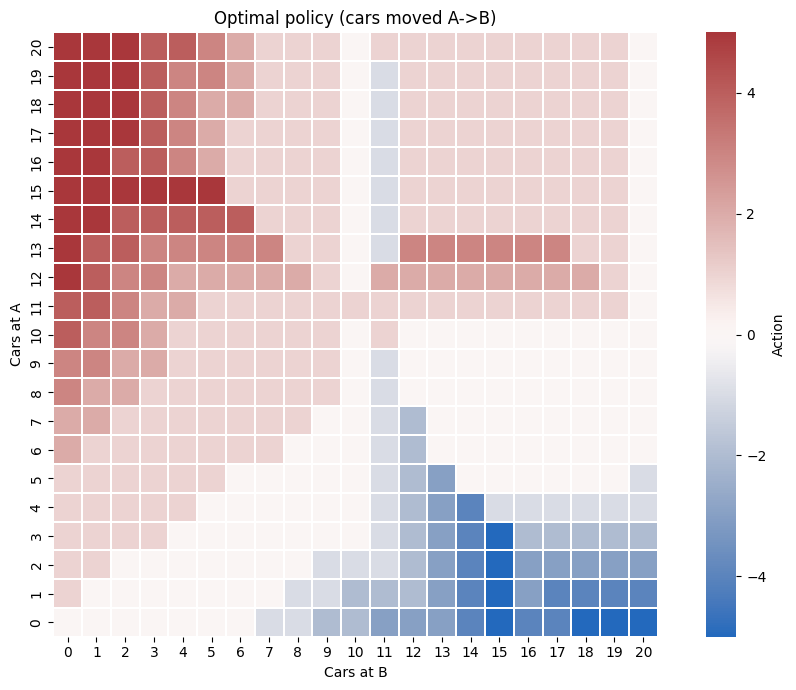

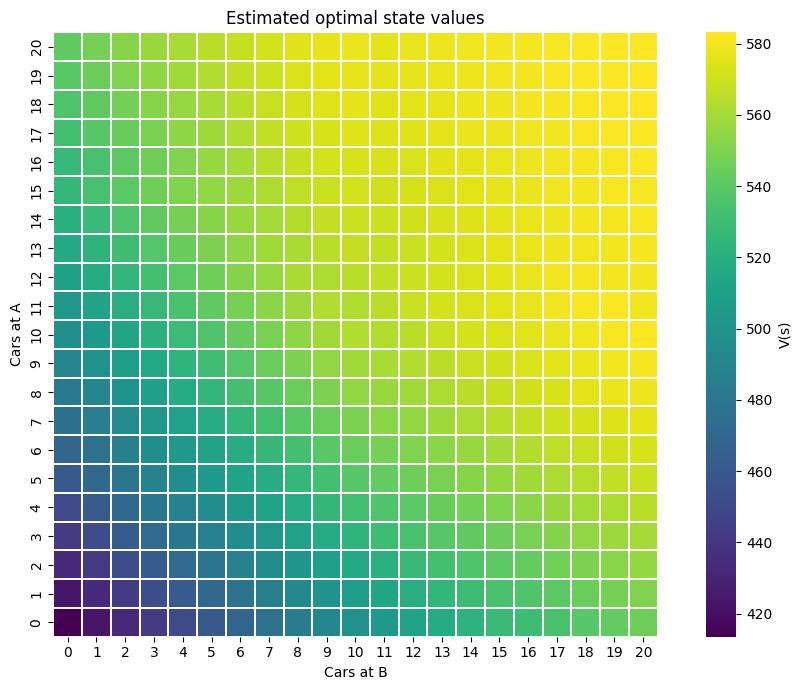

In [9]:
def policy_improvement(V_table, policy_table):
    ########################################################################
    # TODO: greedy policy improvement over all states
    # Return True if policy is stable, else False

    policy_stable = True

    for a in range(MAX_CARS + 1):
        for b in range(MAX_CARS + 1):
            old_action = policy_table[a, b]

            best_action = old_action
            max_val = -np.inf

            # Find the greedy action
            for action in ACTIONS:
                if is_action_legal((a, b), action):
                    val = expected_return((a, b), action, V_table)
                    # Add a tiny epsilon (1e-5) to prevent floating point instability from causing infinite loops on ties
                    if val > max_val + 1e-5:
                        max_val = val
                        best_action = action

            policy_table[a, b] = best_action

            # If any state changes its optimal action, the policy is not yet stable
            if old_action != best_action:
                policy_stable = False

    return policy_stable
    ########################################################################


# After completing the tasks above, run policy iteration below.
# You can reduce max_iterations while debugging.
max_iterations = 20

for it in range(1, max_iterations + 1):
    clear_output(wait=True)
    print(f"Policy Iteration outer loop: {it}")

    policy_evaluation(V, policy, theta=1e-2)
    stable = policy_improvement(V, policy)

    if stable:
        print("Policy converged.")
        break

plot_policy(policy, title="Optimal policy (cars moved A->B)")
plot_values(V, title="Estimated optimal state values")


## Optional checks

- Verify your policy heatmap has structured regions (not random noise).
- Try changing `theta` and compare runtime vs final policy changes.
- Try removing extension rules (free transfer / parking penalty) and compare policies.


# References

- Sutton, R. S., & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2nd ed.), Chapter 4.
